# DS, Mini Project : ESS 배터리 수명 예측 (DAY1)

박준형(U015)

Batch 1·2·3의 수명 분포, 방전 용량, ΔQ(V), 충전 조건, 초기 신호를 비교했습니다. 원자료 추출과 피처 계산은 `src/day1_eda.py`, 배치 비교는 `src/day1_compare.py`에서 수행합니다. 이 노트북에는 저장소에 포함된 분석 결과를 표시합니다. 그래프의 해석과 변수 선택 근거는 `DAY1-REPORT.md`에 정리했습니다.

원논문의 Batch 2는 `2017-06-30` 파일입니다. 공개 전처리 기준을 적용한 분석 표본은 Batch 1·2·3에서 각각 41·43·40셀입니다.

## 결과 열람과 원자료 재생성

아래 셀은 Git에 포함된 `results/` 결과를 읽습니다. **원자료를 다시 계산하거나 검증하지 않습니다.** 원본 `.mat` 파일을 내려받아 모든 결과를 재생성하려면 프로젝트 루트에서 `README.md`의 실행 순서를 따르세요. 원자료·피처·모델 예측의 대조 결과는 `results/audit_results.json`에 있습니다.

In [1]:
from pathlib import Path
ROOT = Path.cwd()
required = [
    'results/batch_summary.csv',
    'results/paper_screened_cells.csv',
    'results/day1_probe_summary.csv',
]
missing = [name for name in required if not (ROOT / name).is_file()]
if missing:
    raise FileNotFoundError(f'결과 파일이 없습니다: {missing}. README.md 순서로 재생성하세요.')
print('저장소에 포함된 분석 결과를 표시합니다. 원자료 재생성 절차는 README.md를 확인하세요.')

저장소에 포함된 분석 결과를 표시합니다. 원자료 재생성 절차는 README.md를 확인하세요.


## 1. 수명 분포와 짧은 수명 셀

배치별 분포와 500사이클 미만·1,000사이클 초과 비율을 비교합니다. 가장 짧은 셀의 충전 정책과 초기 신호도 확인합니다. 수명 레이블이 없는 셀은 비율의 분모에서 제외합니다.

,batch,cells,labeled,mean_life,median_life,min_life,q25_life,q75_life,max_life,pct_short,pct_long,dq_available,knee_available,median_knee
0,batch1,41,41,921.341463,842.0,534.0,702.00,966.00,2237.0,0.000000,24.390244,41,36,579.5
1,batch2,43,43,473.209302,481.0,148.0,461.00,499.00,713.0,76.744186,0.000000,43,43,381.0
2,batch3,40,40,1032.000000,964.5,541.0,827.25,1122.75,1935.0,0.000000,47.500000,40,40,766.0


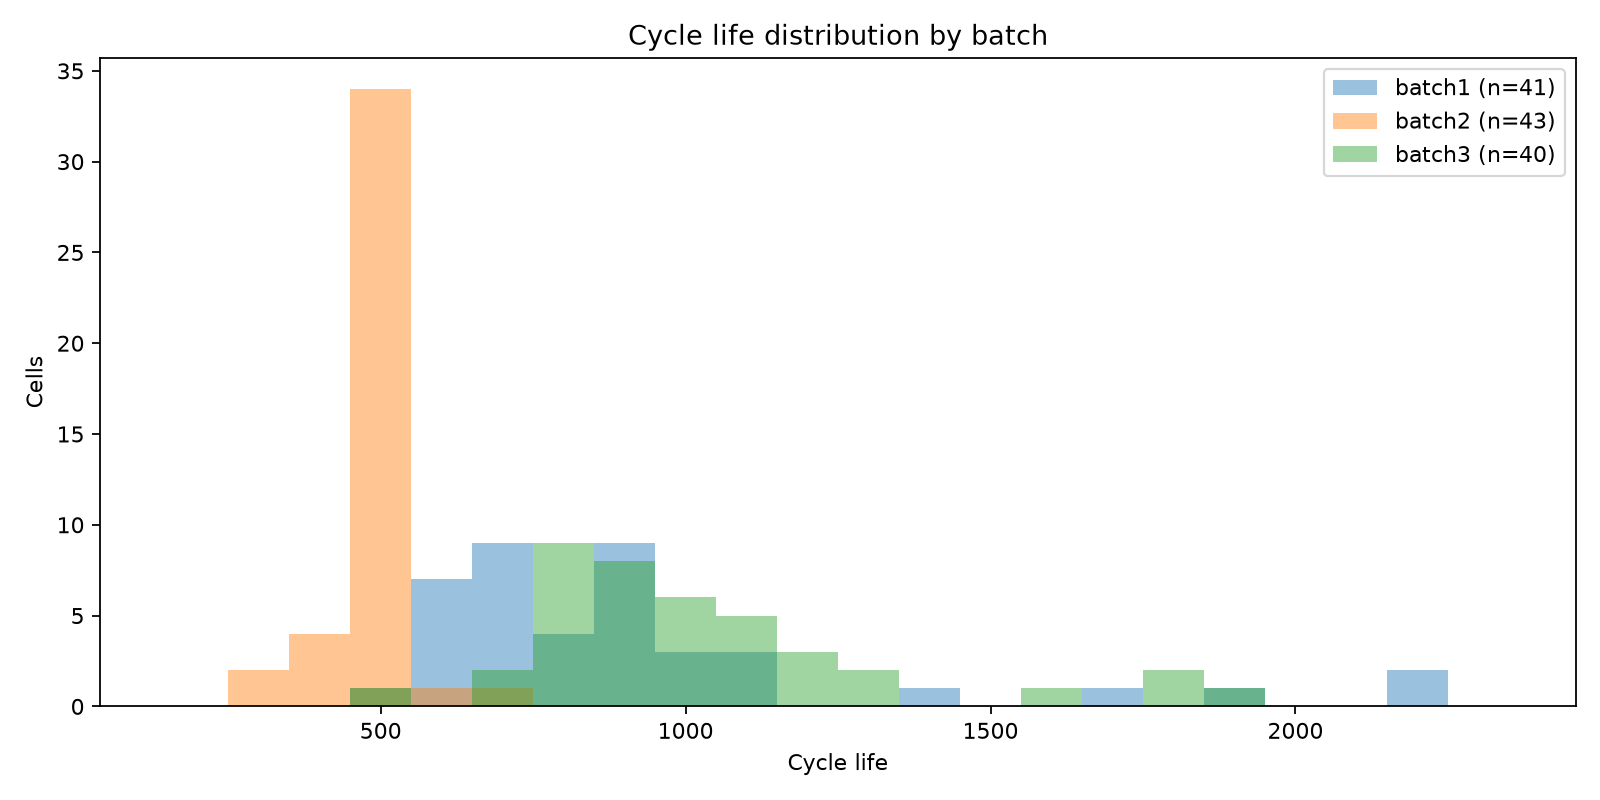

,batch,cell_id,cycle_life,policy,delta_q_logvar
42,batch2,batch2_001,148.0,2C(10%)-6C,-2.727
41,batch2,batch2_000,300.0,1C(4%)-6C,-2.746
44,batch2,batch2_003,335.0,2C(7%)-5.5C,-2.930
77,batch2,batch2_041,429.0,5.6C(65%)-3C,-3.439
82,batch2,batch2_046,429.0,6C(52%)-3.5C,-3.369
43,batch2,batch2_002,438.0,2C(2%)-5C,-3.493
45,batch2,batch2_004,444.0,3.6C(22%)-5.5C,-3.352
80,batch2,batch2_044,457.0,6C(40%)-4C,-3.453


In [2]:
import pandas as pd
from IPython.display import display, Image
summary = pd.read_csv('results/batch_summary.csv')
display(summary)
display(Image(filename='results/figures/compare_life.png'))
cells = pd.read_csv('results/paper_screened_cells.csv')
display(cells.nsmallest(8, 'cycle_life')[['batch','cell_id','cycle_life','policy','delta_q_logvar']].round(3))

## 2. 방전 용량 곡선과 탐색적 knee

세 배치의 QD 곡선을 함께 비교합니다. 두 직선으로 근사한 knee는 후반 열화를 설명하는 데만 사용하며 예측 피처에 넣지 않습니다.

,batch,valid,accelerates,median_knee
0,batch1,36,1.0,579.5
1,batch2,43,1.0,381.0
2,batch3,40,1.0,766.0


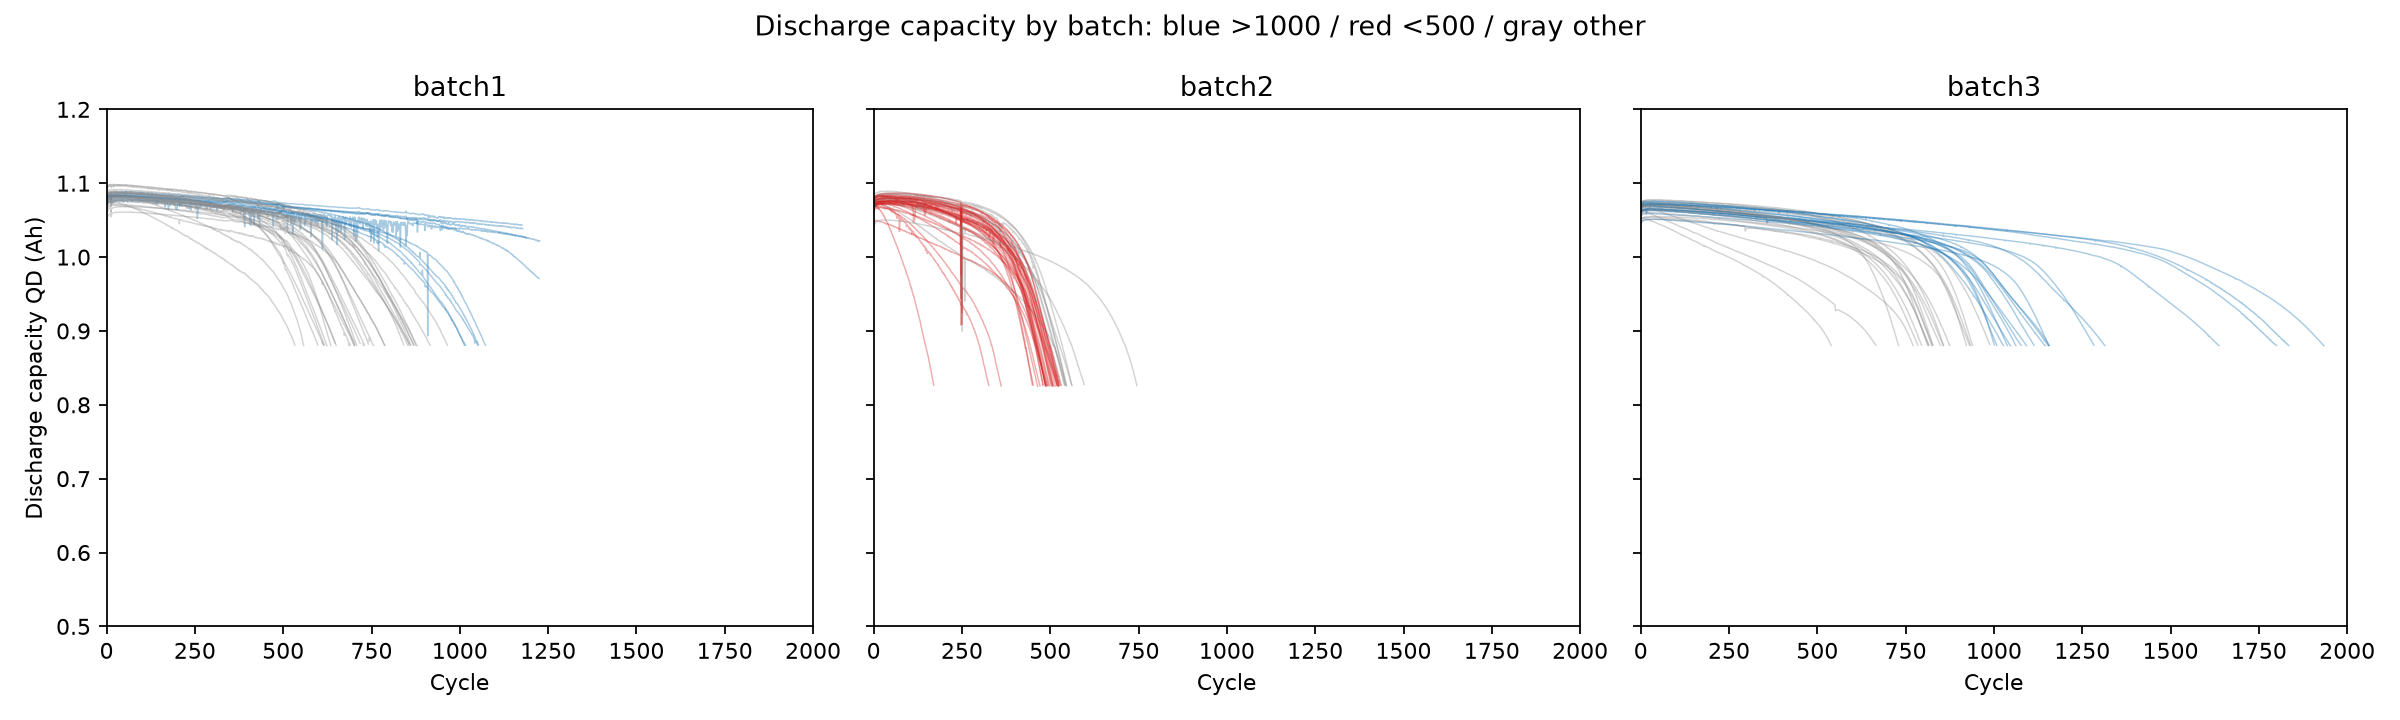

In [3]:
display(pd.read_csv('results/knee_summary.csv'))
display(Image(filename='results/figures/compare_qd.png'))

## 3. 초기 ΔQ(V)와 파생변수

같은 셀에서 100사이클과 10사이클의 `Qdlin(V)` 차이를 계산했습니다. 핵심 후보는 `log10 var(ΔQ(V))`입니다. Batch 1에서만 강한 관계가 나타나는지, 세 배치에서 방향이 유지되는지 확인했습니다.

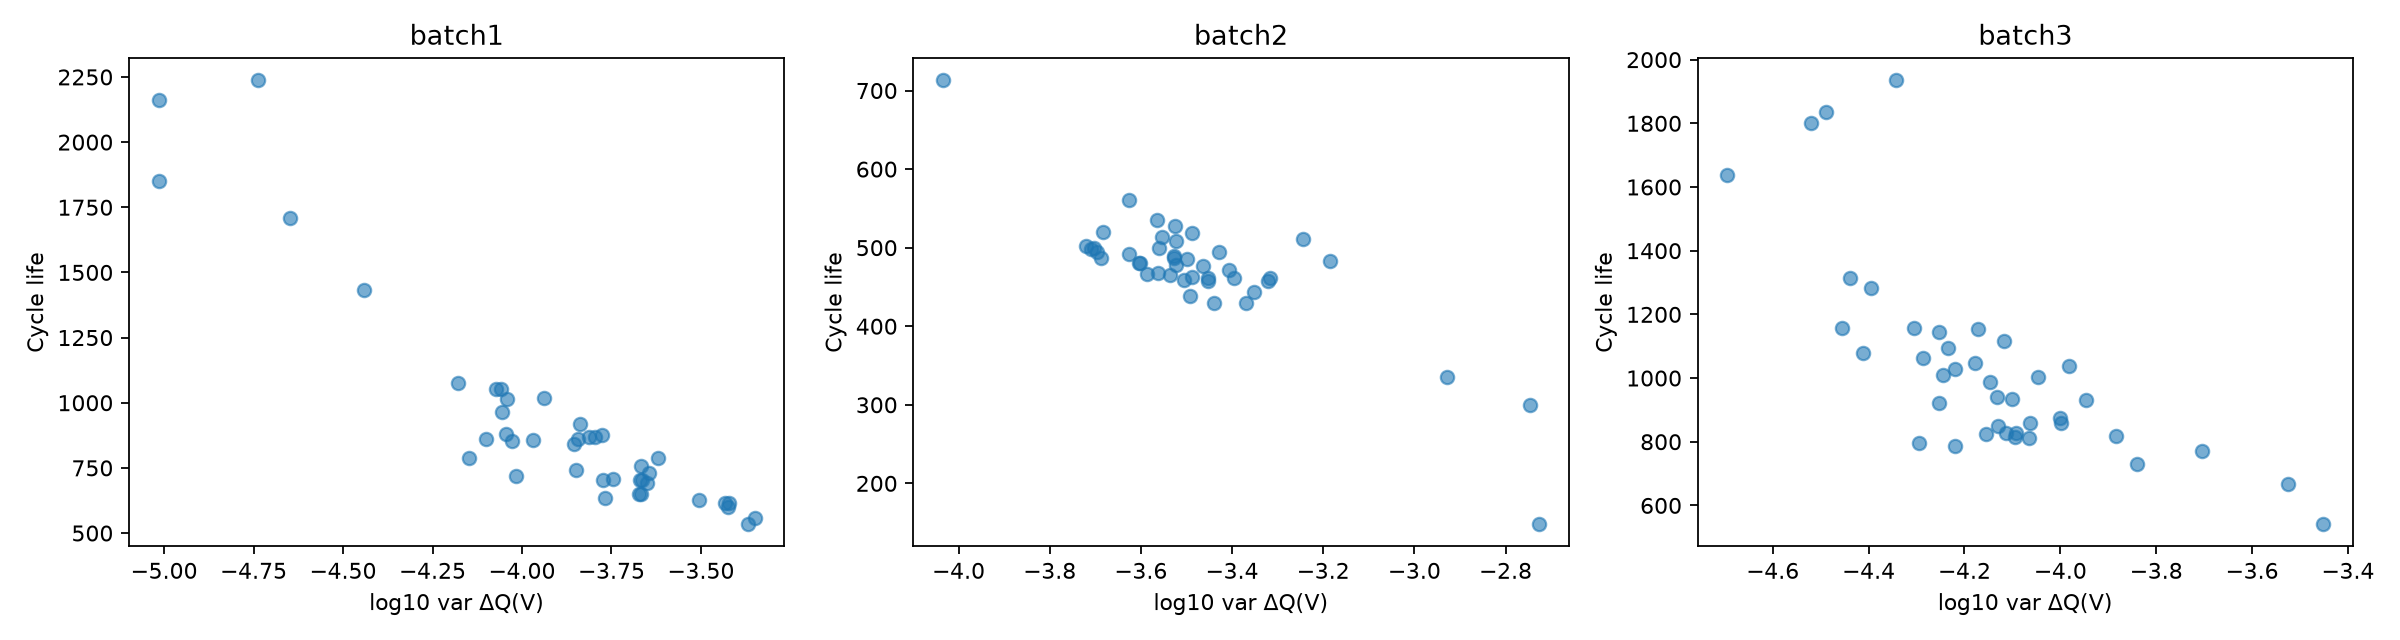

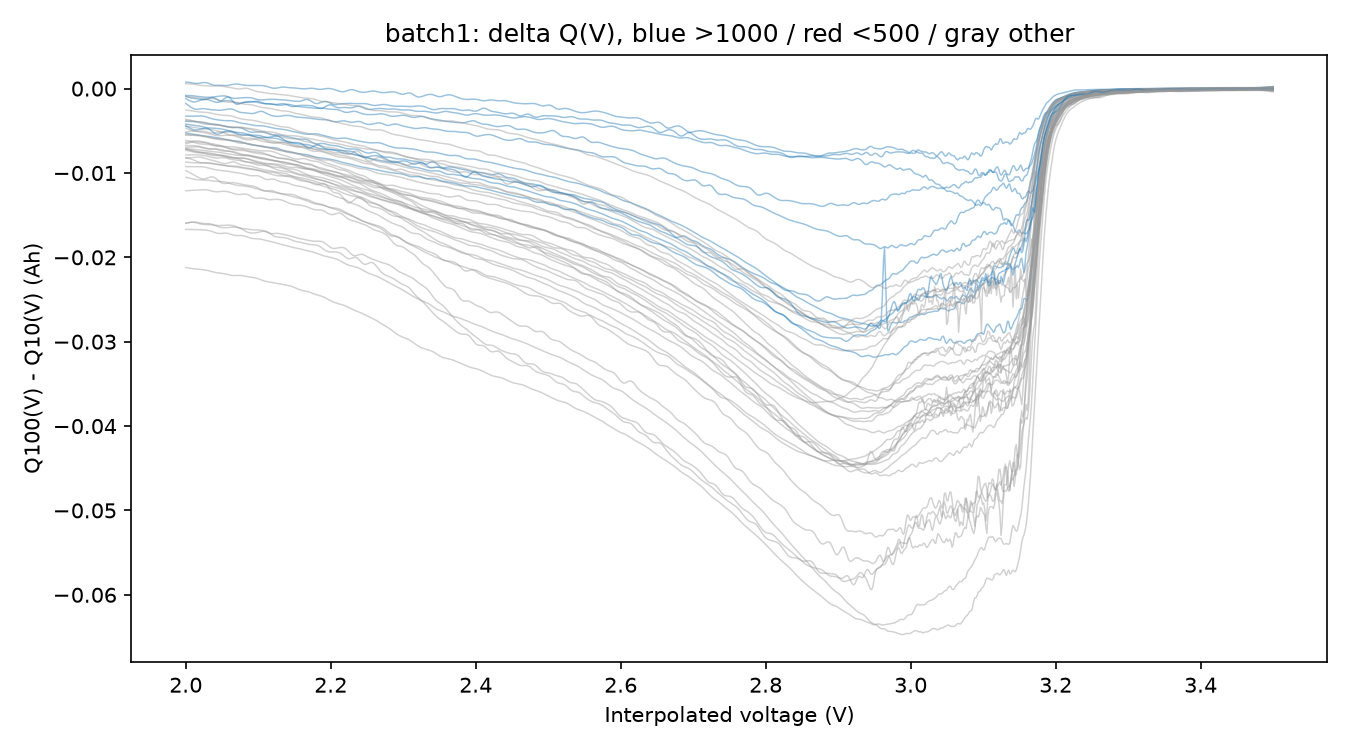

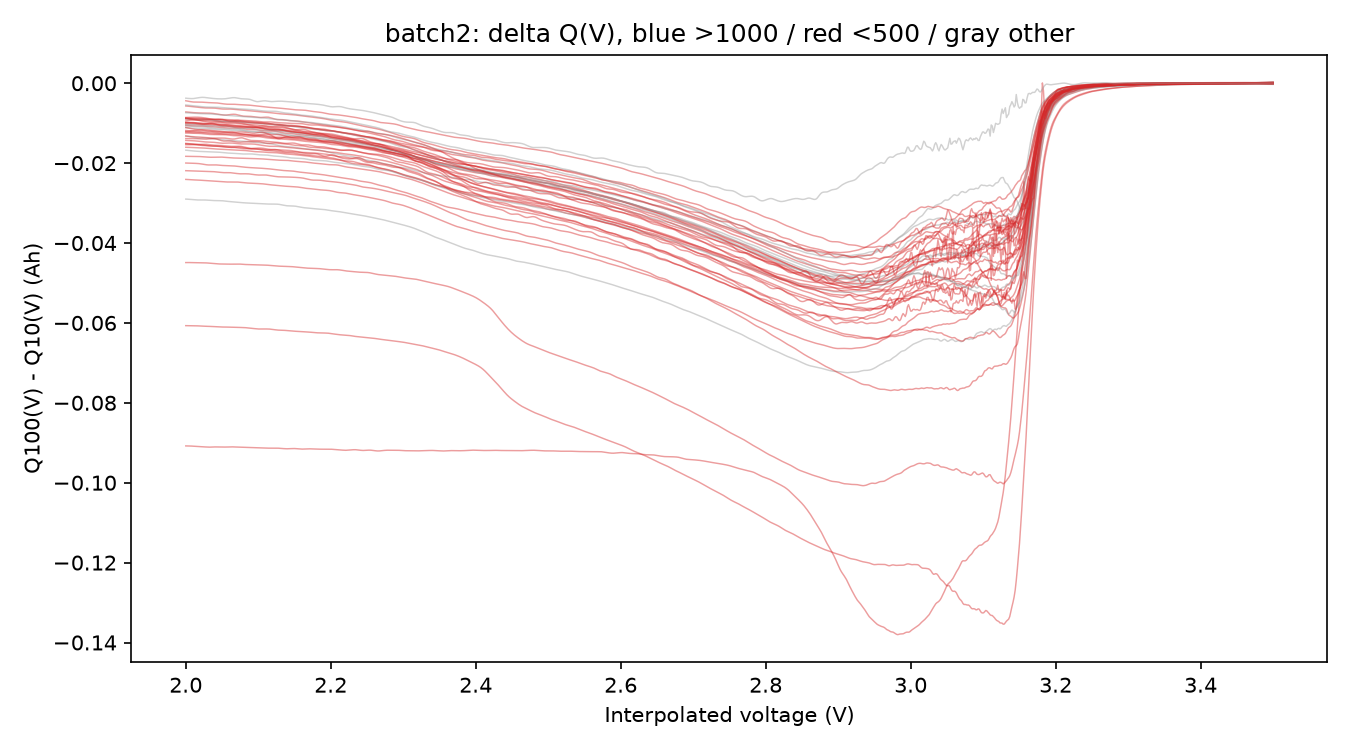

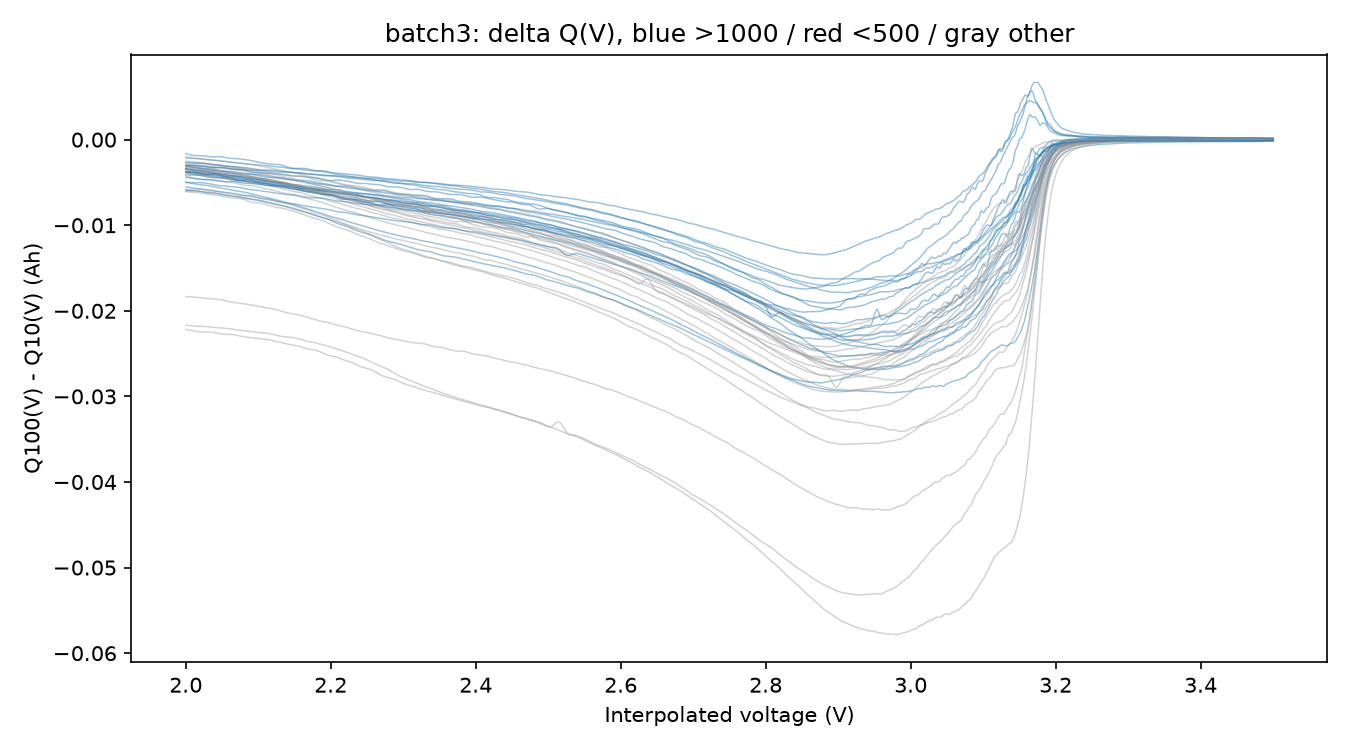

In [4]:
display(Image(filename='results/figures/compare_delta_q.png'))
for batch in ('batch1','batch2','batch3'):
    display(Image(filename=f'results/figures/{batch}_delta_q.png'))

## 4. 충전 정책과 열화 속도

첫 구간 C-rate와 충전 시간뿐 아니라, 0~80% SOC 구간의 C-rate를 구간 길이로 가중한 정책 강도를 비교합니다. 실제 평균 전류를 뜻하는 값은 아닙니다.

,batch,policy,n,mean_life,sd_life,first_c_rate
9,batch1,5.4C(80%)-5.4C,2,546.500000,17.677670,5.4
21,batch1,8C(35%)-3.6C,2,607.500000,12.020815,8.0
17,batch1,7C(40%)-3.6C,2,621.000000,5.656854,7.0
18,batch1,7C(40%)-3C,2,676.000000,39.597980,7.0
20,batch1,8C(25%)-3.6C,2,676.500000,36.062446,8.0
...,...,...,...,...,...,...
67,batch3,5.6C(36%)-4.3C-newstructure,8,930.875000,135.024270,5.6
66,batch3,5.6C(19%)-4.6C-newstructure,7,963.428571,148.689674,5.6
65,batch3,5.3C(54%)-4C-newstructure,8,1074.375000,129.674248,5.3
70,batch3,5C(67%)-4C-newstructure,6,1115.666667,440.424189,5.0


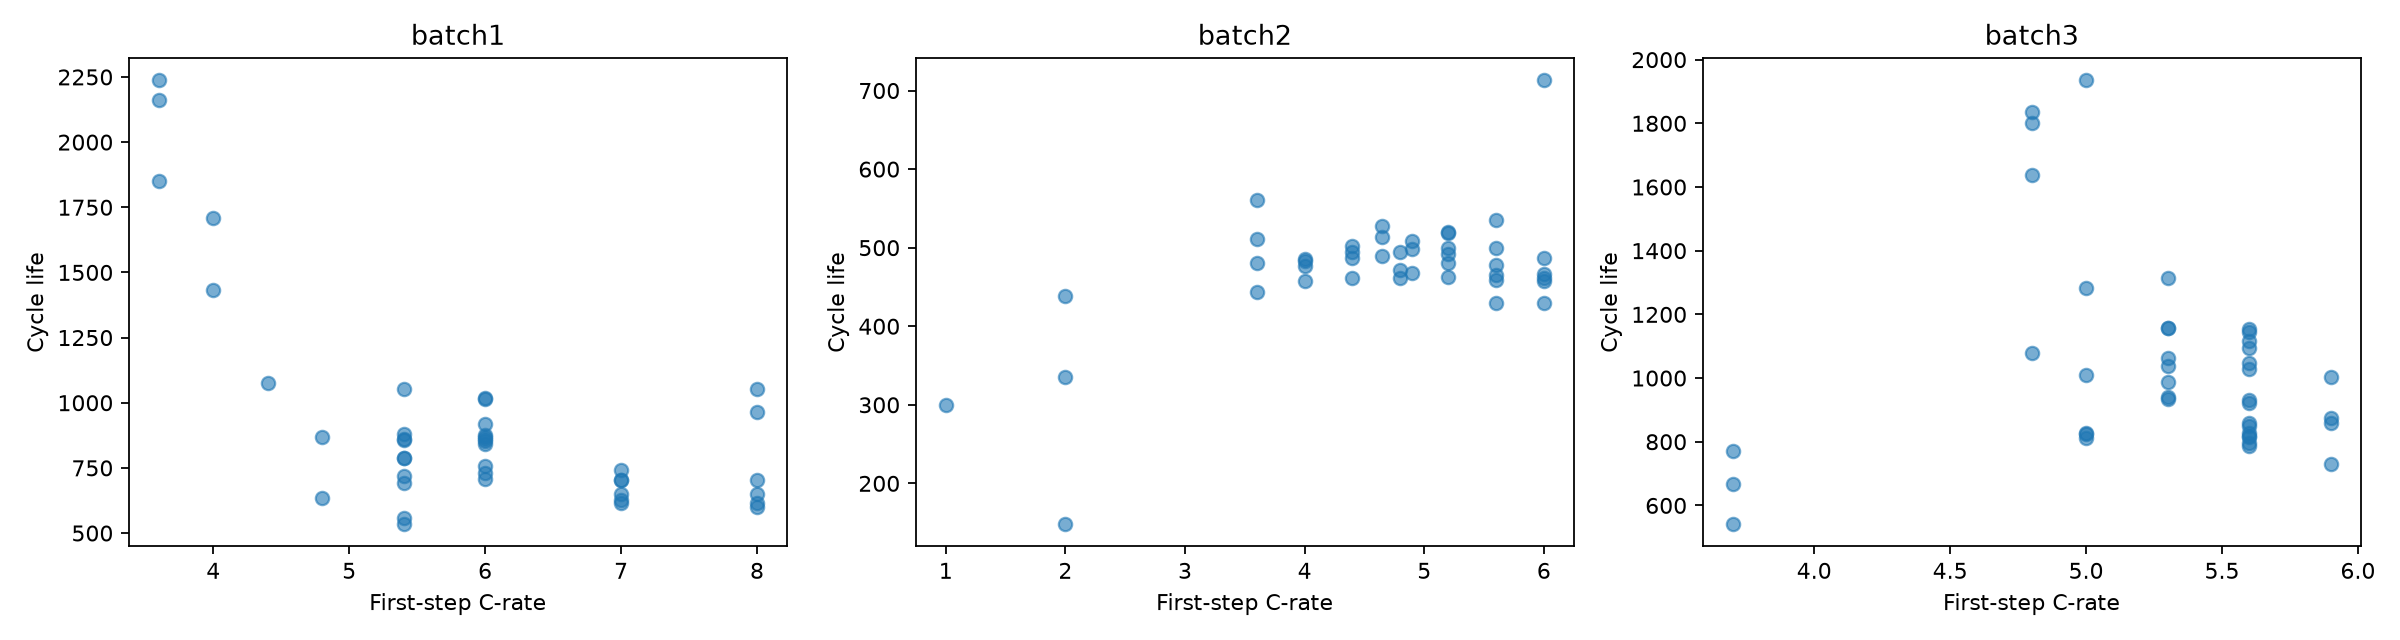

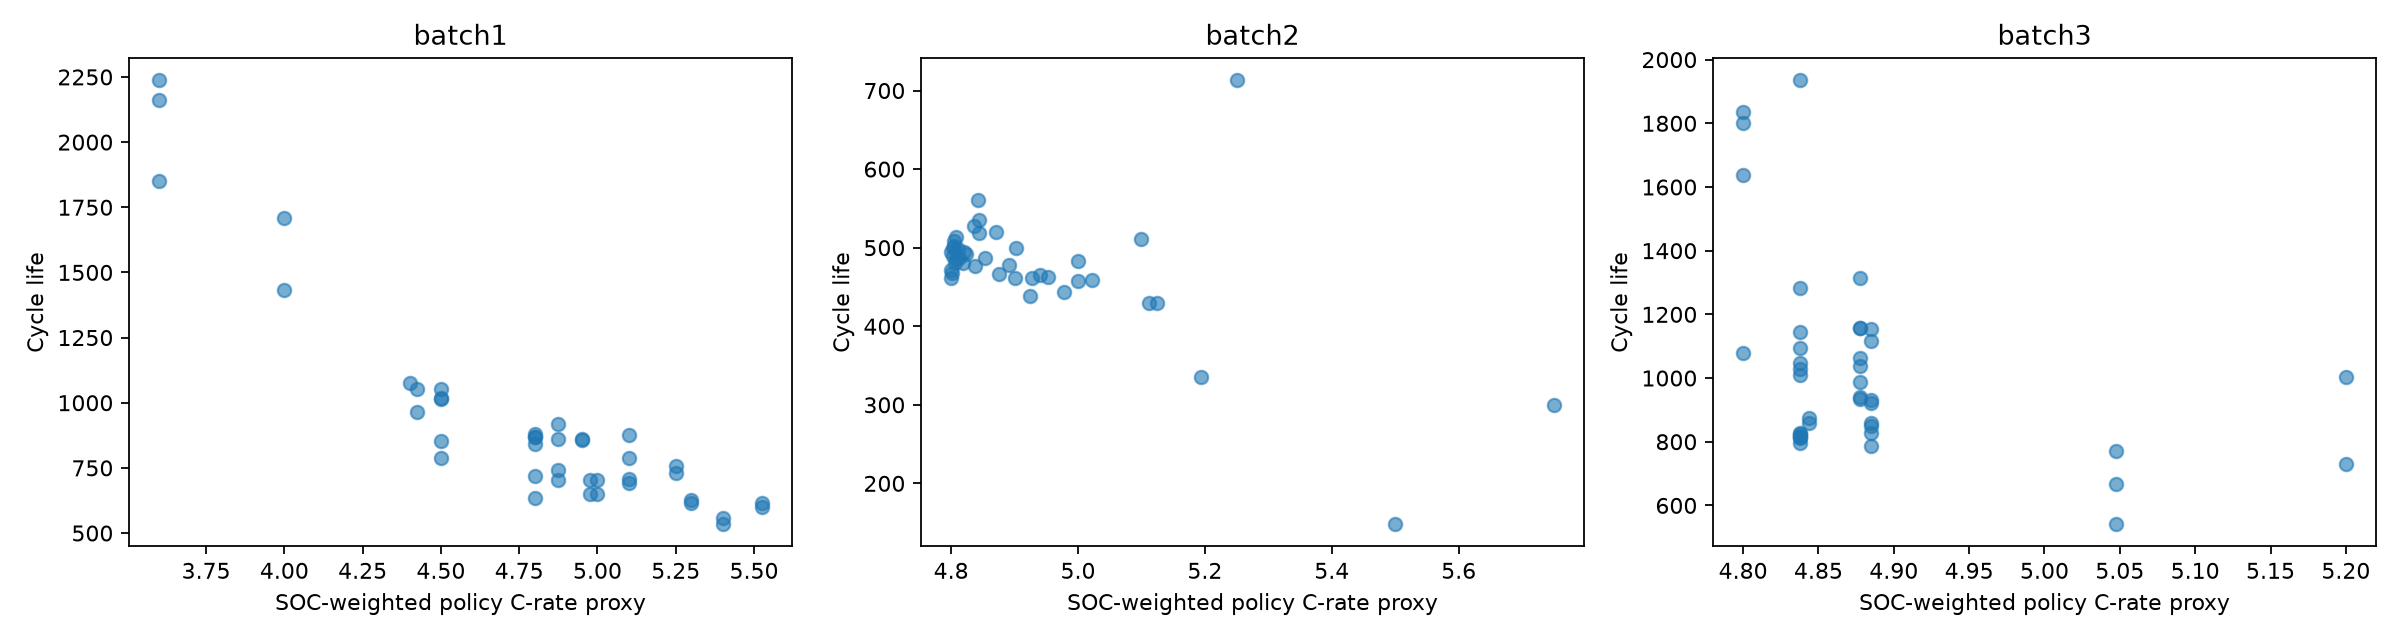

In [5]:
policy = pd.read_csv('results/policy_summary.csv')
display(policy.sort_values(['batch','mean_life']))
display(Image(filename='results/figures/compare_c_rate.png'))
display(Image(filename='results/figures/compare_policy_rate.png'))

## 5. 초기 신호의 상관관계와 변수 중복

초기 신호와 수명의 상관을 배치별로 비교합니다. Batch 1에서는 정책 강도와 ΔQ(V)의 상관도 높아 두 변수의 독립적인 기여를 단정하지 않습니다.

batch,batch1,batch2,batch3
feature,,,
delta_q_logvar,-0.882,-0.646,-0.759
delta_q_mean_abs,-0.836,-0.603,-0.719
early_mean_IR,0.208,0.102,0.213
early_mean_QD,0.189,0.296,0.247
early_mean_Tavg,-0.389,0.085,0.017
early_mean_Tmax,-0.346,0.032,-0.072
early_mean_chargetime,0.603,0.038,0.049
first_c_rate,-0.489,0.137,-0.163
policy_rate_proxy,-0.851,-0.433,-0.428


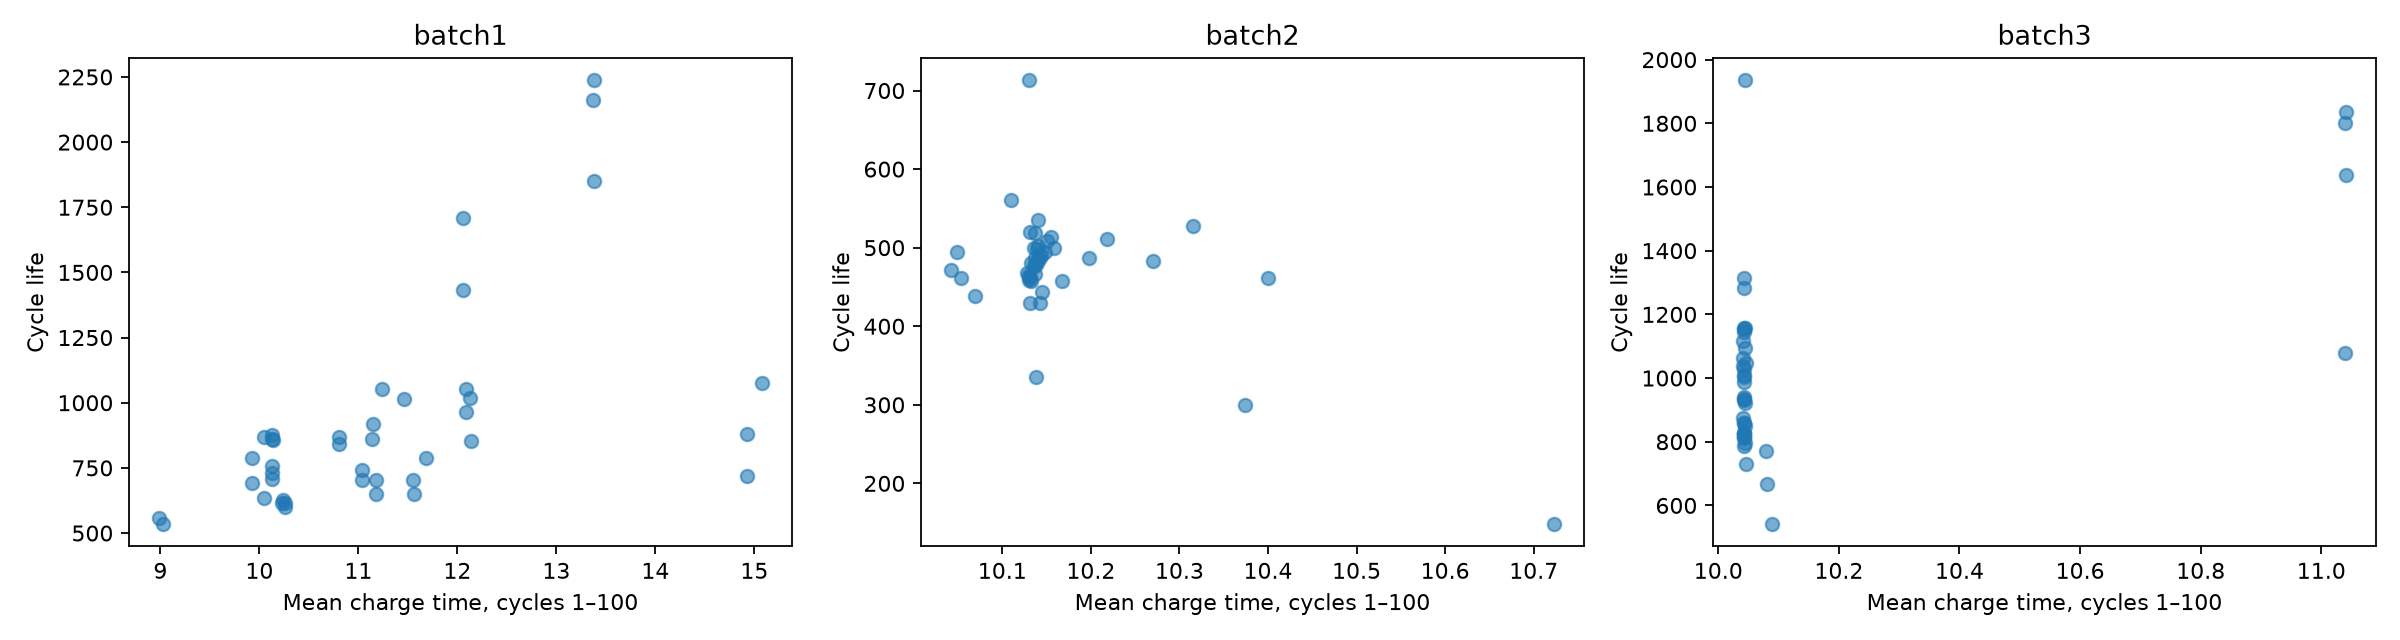

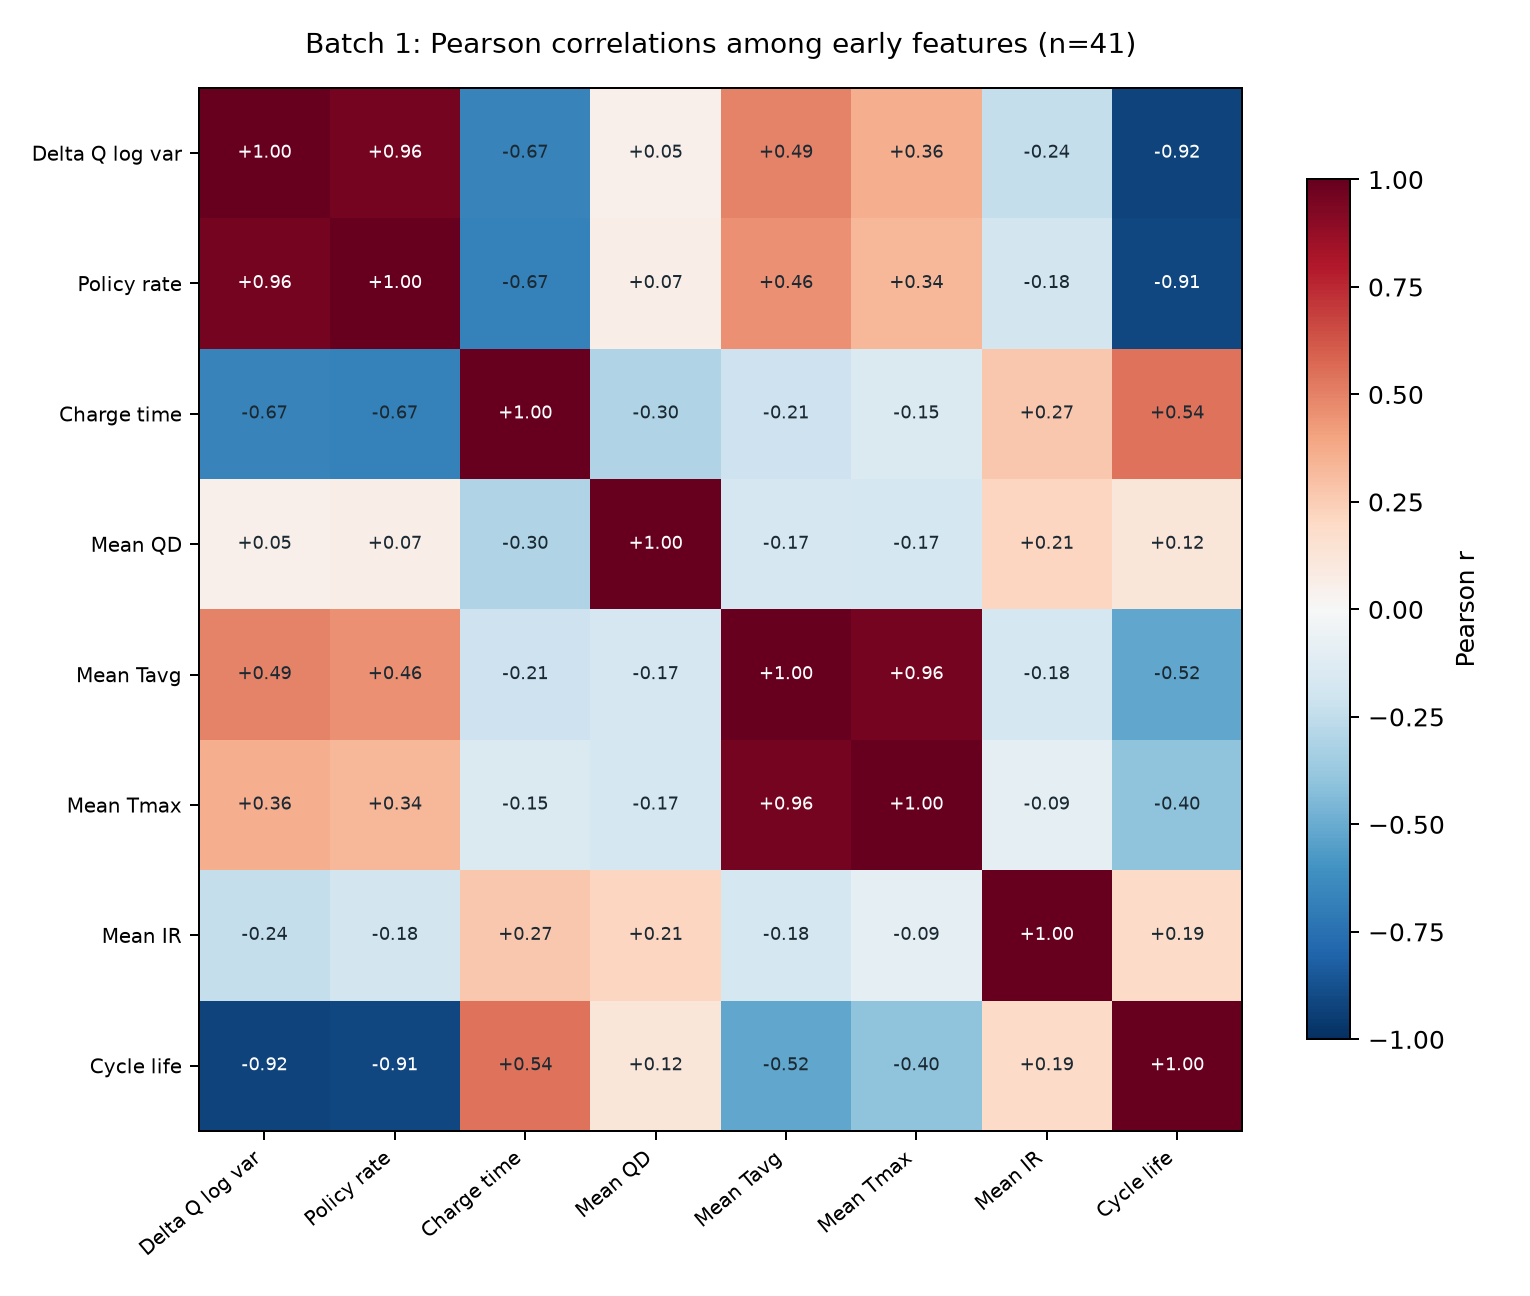

,batch,cell_id,cycle_life,policy,first_c_rate,n_cycles,n_early,early_mean_QD,early_mean_QC,early_mean_IR,...,delta_q_mean_abs,delta_q_min,knee_cycle,slope_before,slope_after,policy_switch_soc,second_c_rate,policy_rate_proxy,life_adjustment_cycles,reference_exclusion
0,batch1,batch1_000,1852.0,3.6C(80%)-3.6C,3.6,1189,100,1.080597,1.080434,0.016643,...,0.002955,-0.008460,NaN,NaN,NaN,80.0,3.6,3.6,662,False
1,batch1,batch1_001,2160.0,3.6C(80%)-3.6C,3.6,1178,100,1.081247,1.081092,0.016922,...,0.004100,-0.011004,NaN,NaN,NaN,80.0,3.6,3.6,981,False
2,batch1,batch1_002,2237.0,3.6C(80%)-3.6C,3.6,1176,100,1.085371,1.085146,0.016769,...,0.004487,-0.017216,NaN,NaN,NaN,80.0,3.6,3.6,1060,False
3,batch1,batch1_003,1434.0,4C(80%)-4C,4.0,1225,100,1.084949,1.084546,0.016311,...,0.007468,-0.018961,NaN,NaN,NaN,80.0,4.0,4.0,208,False
4,batch1,batch1_004,1709.0,4C(80%)-4C,4.0,1226,100,1.082844,1.082700,0.016669,...,0.005751,-0.013958,NaN,NaN,NaN,80.0,4.0,4.0,482,False


In [6]:
corr = pd.read_csv('results/feature_correlations.csv')
display(corr.pivot(index='feature', columns='batch', values='spearman').round(3))
display(Image(filename='results/figures/compare_charge_time.png'))
display(Image(filename='results/figures/batch1_feature_heatmap.png'))
display(pd.read_csv('results/paper_screened_cells.csv').head())

## 6. 후보 모델 선정과 Batch 1 사전 비교

중앙값 예측을 기준선으로 두고, 변수 중복과 적은 셀 수를 고려해 Ridge·Elastic Net을 비교합니다. 얕은 트리는 비선형 관계를 확인하는 후보입니다. 충전 정책별 5분할 검증에서 ΔQ(V) 단독 Ridge와 핵심 세 변수 Elastic Net이 약 12.97%였습니다. Day 2에는 로그 타깃 Ridge를 포함해 후보를 다시 비교합니다. Batch 2 점수는 이 단계에서 계산하지 않았습니다.

,experiment,mean_mape_pct,sd_mape_pct,mean_mae_cycles,pooled_mape_pct,pooled_mae_cycles
0,elasticnet_compact,12.97,6.70,116.27,13.03,118.69
1,ridge_delta_only,12.97,6.76,114.85,13.12,117.76
2,ridge_compact,13.27,7.27,117.53,13.33,119.83
3,tree_compact,13.86,9.18,153.67,14.25,160.55
4,ridge_compact_with_policy,14.35,7.54,126.66,14.34,128.51
5,ridge_policy_proxy_only,16.88,6.40,152.63,16.88,155.08
6,ridge_basic,19.28,11.79,184.94,19.76,191.87
7,median_baseline,22.96,4.95,241.85,23.10,248.35


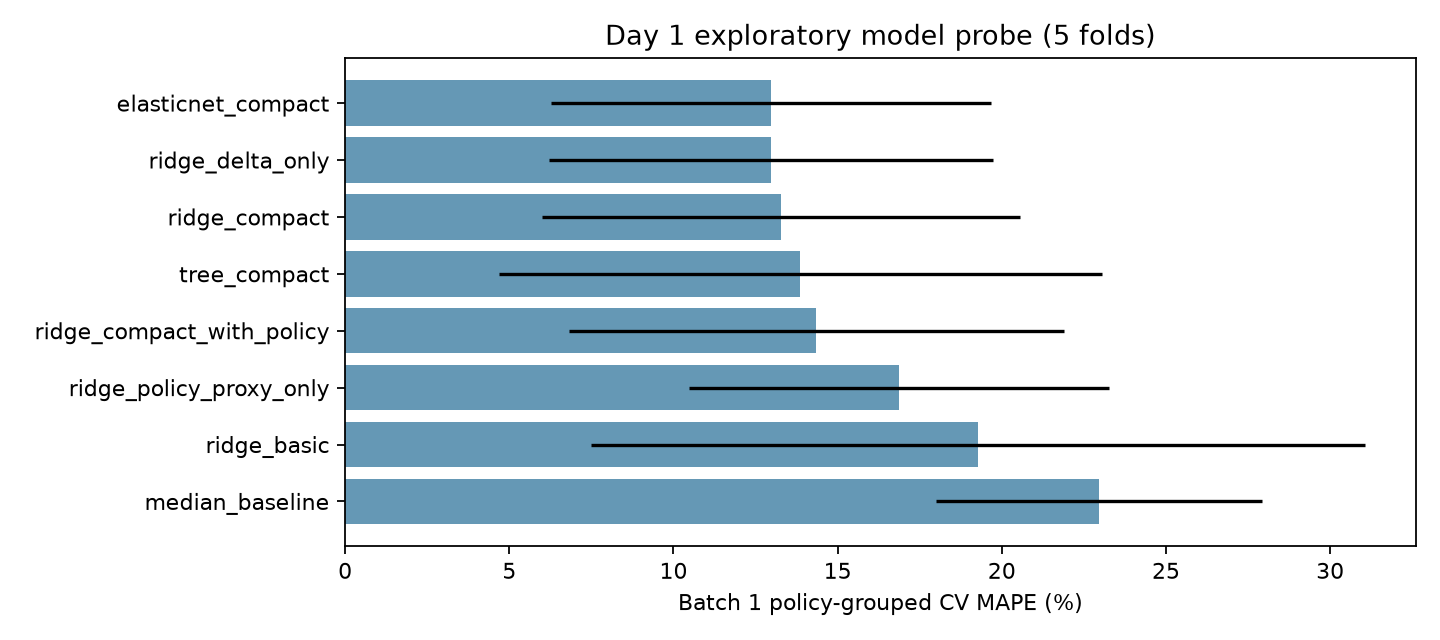

,experiment,cell_id,policy,fold,actual,predicted,abs_error
166,ridge_compact,batch1_002,3.6C(80%)-3.6C,1,2237.0,1542.1,694.9
165,ridge_compact,batch1_001,3.6C(80%)-3.6C,1,2160.0,1729.4,430.6
180,ridge_compact,batch1_020,5.4C(80%)-5.4C,4,534.0,253.3,280.7
176,ridge_compact,batch1_016,5.4C(60%)-3.6C,2,862.0,1139.0,277.0
197,ridge_compact,batch1_038,7C(40%)-3.6C,2,617.0,388.7,228.3
173,ridge_compact,batch1_011,5.4C(50%)-3C,1,788.0,989.2,201.2
175,ridge_compact,batch1_015,5.4C(60%)-3C,1,719.0,916.2,197.2
181,ridge_compact,batch1_021,5.4C(80%)-5.4C,4,559.0,392.5,166.5


In [7]:
probe = pd.read_csv('results/day1_probe_summary.csv')
display(probe.round(2))
display(Image(filename='results/figures/day1_probe.png'))
pred = pd.read_csv('results/day1_probe_predictions.csv')
ridge = pred[pred.experiment == 'ridge_compact']
display(ridge.sort_values('abs_error', ascending=False).head(8).round(1))